# Table of Contents

1. Introduction
2. Bar Charts
2.1 Preliminary Data Grouped Bar Chart - Utah Teapot
2.2 Stacked Bars
3. Scatter Plots
4 Scatter Plots and Stacked Bar Charts


# Introduction

This notebook seeks to carry out analysis of data collected from the preliminary experiments.
The data is contained in a spreadsheet file called **PreliminaryExperimentResults.xlsx**.
The results are organised into 2 sheets(Sheet1 and Sheet2) with each sheet having 2 sets of experiments distringuished by the model(3D model) column.

The first set of experiments are contained in Sheet1 . The factors being explored in these experiments include:
    1. Nmber of photos.
    2. Pattern used
    3. Working Distance
    4. Lamp Presence
    
The seconds set of experiments have their results in **Sheet2** and seek to further explore the circular pattern at various working distances. The factors of intereset are:
    1. InnerPhotos
    2. OuterPhotos
    3. InnerWD

In [6]:
# Load the necessary python modules
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [7]:
# Load data of the second data experiments
df = pd.read_excel('PreliminaryExperimentResults.xlsx', sheet_name='Sheet2', header=2)

# Filter the UtahTeapot data
ut2_chart_df = df[df['Model'] == "UtahTeapot"]
ut2_chart_df = ut2_chart_df[['Pattern','OuterPhotos', 'InnerPhotos', 'InnerWD', 'Elevations', 'RMS']]

# Filter the RandomShape2
rs2_chart_df = df[df['Model'] == "RandomShape2"]
rs2_chart_df = rs2_chart_df[['Pattern','OuterPhotos', 'InnerPhotos', 'InnerWD', 'Elevations', 'RMS']]

# Bar Charts
Plotting data points as individual bars.

Since the `Axes.bar()` method is called for each bar, one can easily set the bar widths.

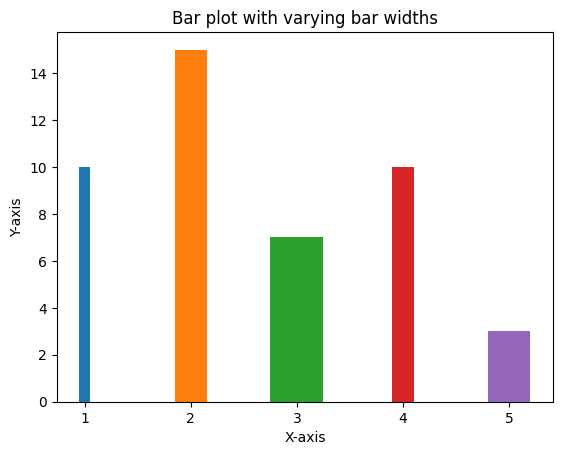

In [13]:
import matplotlib.pyplot as plt

# Sample data for plotting
x = [1, 2, 3, 4, 5]
y = [10, 15, 7, 10, 3]
widths = [0.1, 0.3, 0.5, 0.2, 0.4]

# Plot each bar individually with its own width
for i in range(len(x)):
    plt.bar(x[i], y[i], width=widths[i])

plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.title('Bar plot with varying bar widths')
plt.show()

## Preliminary Data Grouped Bar Chart - Utah Teapot

Each group has a width proportional to the dependent variable.

The values of each column are on top of the bars.


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


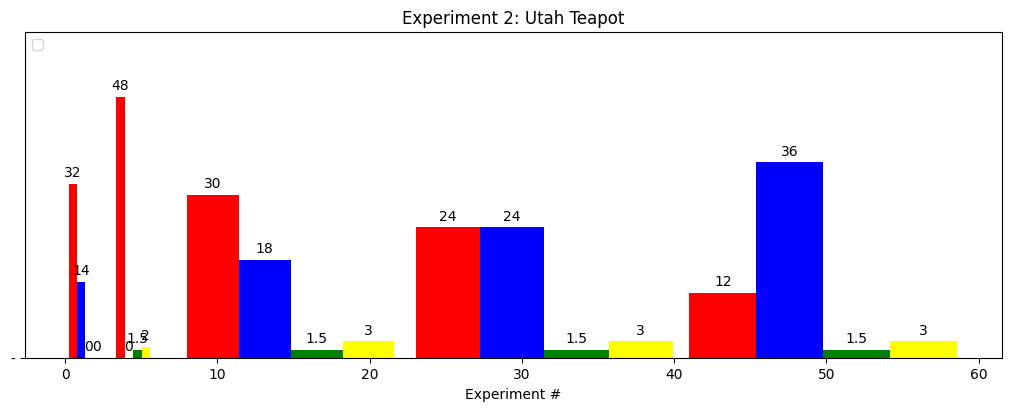

In [14]:
# Loop through the rows of data frame:
fig, ax = plt.subplots(figsize=(10,4), layout='constrained')

offset = 0
spacing = 1;
x_pos = 0

# Provide colors for each 
colorDict = {
    'OuterPhotos'  : "red",
    'InnerPhotos' : "blue",
    'InnerWD': "green",
    'Elevations': 'Yellow'
}

for index, row in ut2_chart_df.iterrows():
    barSize = row["RMS"] * 3
    for index, value in enumerate(list(ut2_chart_df.columns)):
        if value != "RMS" and value != "Pattern" :
            x_pos = offset + (index*barSize)
            rects = ax.bar(x_pos, row[value], width=barSize, color=colorDict[value] )
            ax.bar_label(rects, padding=3)
    offset = spacing + x_pos
    

plt.xlabel("Experiment #")
plt.title("Experiment 2: Utah Teapot")
ax.set_ylim(0,60)
ax.legend(loc='upper left', ncols=3)
plt.show()

## Stacked Bars
Plot's every group as a stacked chart. Utilise border width and colors to represent independent variables with unfavourable scales for the bar.

`plt.bar(labels, values, color='lightblue', edgecolor='black', linewidth=lwidth)`

In [21]:
def add_outline(text, linewidth, color):
    """
    Add an outline to a text object.
    """
    text.set_path_effects([withStroke(linewidth=linewidth, foreground=color)])
    return text

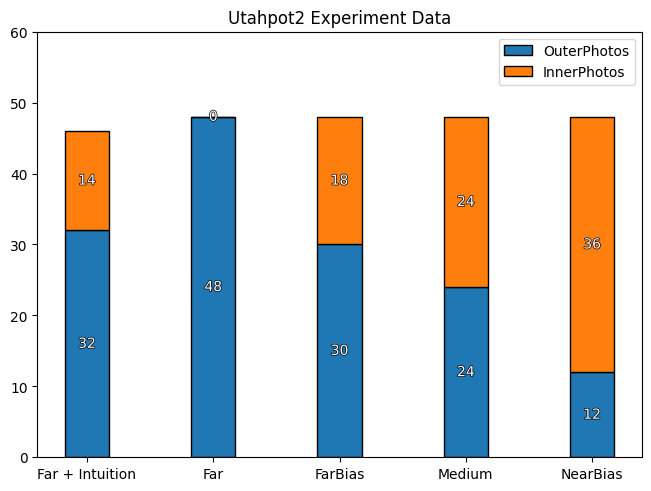

In [31]:
# Extract Labels for each Trial
trialLabel = list(ut2_chart_df["Pattern"])

# Factors of Interest
columns = ["InnerPhotos", "OuterPhotos"]

fig, ax = plt.subplots(constrained_layout=True)
bottom = np.zeros(5)
width = 0.35  # Adjust the width according to your preference

# Loop over columns of the dataframe
# For every loop, each trial has their corresponding factor plotted
for col in ut2_chart_df.columns:
    if col in columns:
        data = np.asarray(list(ut2_chart_df[col]))
        rects = ax.bar(trialLabel, data, width, label=col, bottom=bottom, edgecolor='black', linewidth=1)
        bottom += data

        text_color = '#fff'
        label_params = dict(label_type='center', color=text_color)
        labels = ax.bar_label(rects, **label_params)
        
        # Add black outline to white text
        for label in labels:
            add_outline(label, linewidth=1, color='black')


ax.set_title('Utahpot2 Experiment Data')
ax.legend(loc="upper right")
ax.set_ylim(0, 60)
plt.show()

# Scatter Plots

Create Scatter Plots for Individual Factors

In [23]:

def scatter_plot(ax, x, y, title='', x_label='', y_label='', marker='o', alpha=1.0, size=50, grid=True, label=None):
    """
    Helper function fo Scatter Plots
    Create a scatter plot using Matplotlib's object-oriented approach.
    """

    # Scatter plot with label
    sc = ax.scatter(x, y, marker=marker, alpha=alpha, s=size, label=label)

    # Set plot title and axis labels
    ax.set_title(title)
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)

    ax.grid(True)

    # Display legend if label is provided
    if label:
        ax.legend()


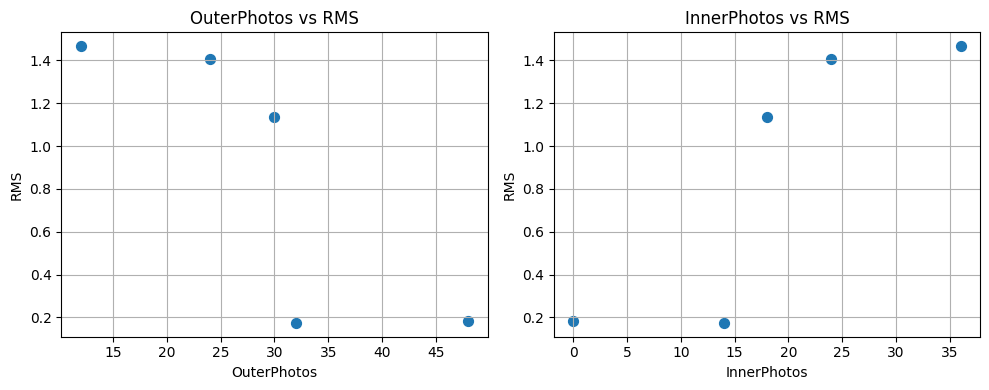

In [24]:
# Factors of Interest
columns = ["InnerPhotos", "OuterPhotos"]

# Instantiate multiple axes for 3 different plots
fig, axes = plt.subplots(1, len(columns), figsize=(10, 4))

ax_count = 0
for _column in ut2_chart_df.columns:
    if _column in columns:
        scatter_plot( axes[ax_count], ut2_chart_df[_column], ut2_chart_df["RMS"], 
                     x_label=_column, y_label="RMS", title=f"{_column} vs RMS" )
        ax_count += 1
        
plt.tight_layout()
plt.show()


# Scatter Plots and Stacked Bar Charts

The stacked bar charts can be used to represent the Number of Photos while the scatter plots are for visualing other data.



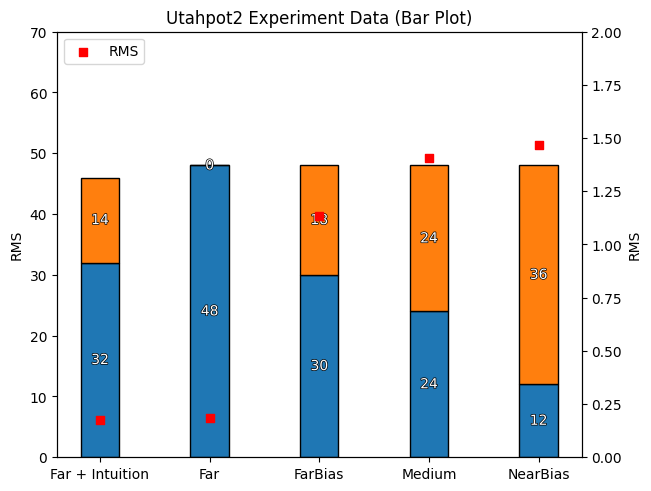

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patheffects import withStroke

# Extract Labels for each Trial
trialLabel = list(ut2_chart_df["Pattern"])

# Factors of Interest
columns = ["InnerPhotos", "OuterPhotos"]

fig, ax = plt.subplots(constrained_layout=True)
ax2 = ax.twinx()  # Create a secondary y-axis on the right
bottom = np.zeros(5)
width = 0.35  # Adjust the width according to your preference

# Loop over columns of the dataframe
# For every loop, each trial has their corresponding factor plotted
for col in ut2_chart_df.columns:
    if col in columns:
        data = np.asarray(list(ut2_chart_df[col]))
        rects = ax.bar(trialLabel, data, width, label=col, bottom=bottom, edgecolor='black', linewidth=1)
        bottom += data

        text_color = '#fff'
        label_params = dict(label_type='center', color=text_color)
        labels = ax.bar_label(rects, **label_params)

        # Add black outline to white text
        for label in labels:
            add_outline(label, linewidth=1, color='black')

y_scatter = list(ut2_chart_df["RMS"])

ax2.scatter(trialLabel, y_scatter, color='red', marker="s", label='RMS', alpha=1)
ax2.set_ylim(0, 2)  # Set the secondary y-axis limits

# Set titles and legends
ax.set_title('Utahpot2 Experiment Data (Bar Plot)')
ax.set_ylabel('RMS')
ax2.set_ylabel('RMS')
ax2.legend(loc="upper left")

ax.set_ylim(0, 70)  # Adjust the primary y-axis limits

plt.show()
